<a href="https://colab.research.google.com/github/DanielaDSMS/Evidence-of-AI-related-skills/blob/main/Macaya_MP3MTB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 <h1 align="center">
  <font color="#8E44AD" face="Georgia", size = "10">Mini proyecto 3 </font><br>
  <font color="#5A189A" face="Georgia" size="10">Minería de textos biomédicos</font>
</h1>



<font color="#240046" face="Georgia" size="4">
Profesora: Rosa Figueroa</font>
<br>
<font color="#240046" face="Georgia" size="4">
Alumno ayudante: José Pinto </font>
<br>
<font color="#240046" face="Georgia" size="4">
19 Junio 2026 </font>
<br>
<font color="#240046" face="Georgia" size="4">
Estudiante: Daniela Macaya</font>
</h1>



<font color="#240046" face="Georgia" size="5">
Ejercicio 1
</h1>


1. Carga, Análisis de Datos y Balance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split #para split manual

# Cargar los archivos
labels_df = pd.read_csv("medical_tc_labels.csv", names=["condition_label", "condition_name"], header=0) #etiqueta de cada numero que aparece en medical tc con una categoria
train_df = pd.read_csv("medical_tc_train.csv") #segun el excel muestra un numero y el analisis del tecnico del medico
test_df = pd.read_csv("medical_tc_test.csv") #es lo mismo que el de arriba pero dividido para prueba y no entrenamiento

# estas lineas son para combinar las etiquetas con ssus correspondientes numeros

label_map = dict(zip(labels_df["condition_label"], labels_df["condition_name"])) #crea tuplas donde el primer elemento es un numero y el siguiente es la condicion asociada
train_df["category"] = train_df["condition_label"].map(label_map) #Para cada fila en el DataFrame train_df, toma el valor de la columna condition_label y busca para cada numero su condicion
test_df["category"] = test_df["condition_label"].map(label_map) # hace lo mismo pero para train, se pudo haber juntado ya que hacen lo mismo pero lo pense tarde :p

# Aca se renombra la columna de texto para guardar lo que se hizo
train_df = train_df.rename(columns={"medical_abstract": "text"}) #text se refiere a la columna que contiene las categorias de los resumenes medicos
test_df = test_df.rename(columns={"medical_abstract": "text"})

print(f"Tamaño del set de entrenamiento original: {train_df.shape[0]} muestras") #imprimir el tamaño para saber en cuanto la divididieron por defecto
print(f"Tamaño del set de prueba original: {test_df.shape[0]} muestras")
#mostrando una diferencia de 2888/11550 que da 0.250043 es decir aproximadamente un test/train de 20/80

Tamaño del set de entrenamiento original: 11550 muestras
Tamaño del set de prueba original: 2888 muestras


Análisis Exploratorio del Corpus y balance de clases

In [ ]:
# Combinamos momentáneamente para hacer el análisis
full_corpus = pd.concat([train_df, test_df], axis=0).reset_index(drop=True) #con los cambios hechos en la parte superior

print("Análisis de Valores Nulos") #sin valores nulos
print(full_corpus.isnull().sum())

print("\n Distribución de Muestras por Categoría Clínica") #muy distintos
distribucion_clases = full_corpus["category"].value_counts()
print(distribucion_clases)

print("\n Proporciones Relativas") # diferencia marcada de 5 categorias hay 1 que abarca un tercio aprox y otra apenas un decimo de todo
print(full_corpus["category"].value_counts(normalize=True) * 100) #esta funcion es para verlo en proporcion (%) y no en decimales

Análisis de Valores Nulos
condition_label    0
text               0
category           0
dtype: int64

 Distribución de Muestras por Categoría Clínica
category
general pathological conditions    4805
neoplasms                          3163
cardiovascular diseases            3051
nervous system diseases            1925
digestive system diseases          1494
Name: count, dtype: int64

 Proporciones Relativas
category
general pathological conditions    33.280233
neoplasms                          21.907466
cardiovascular diseases            21.131736
nervous system diseases            13.332872
digestive system diseases          10.347694
Name: proportion, dtype: float64


Presencia de valores nulos: El dataset se encuentra completamente limpio, registrando $0$ valores nulos en todas sus columnas (condition_label, text y category).

Tamaño del corpus: El volumen total asciende a 14,438 muestras (11,550 en el set de entrenamiento y 2,888 en el de prueba)

Conclusión de Balance: El dataset se encuentra fuertemente desbalanceado . La clase mayoritaria (general pathological conditions) triplica en volumen a la clase minoritaria (digestive system diseases).


Preprocesamiento Diferenciado


In [ ]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Descargar recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) # El corpus está en inglés

# PREPROCESAMIENTO general
def preprocess_for_classification(text):
    # minúsculas todo
    text = text.lower()
    # Tokenizar palabras
    tokens = word_tokenize(text)
    # Eliminar puntuación, stopwords y lematizar
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        for c in token if c not in string.punctuation and token not in stop_words
    ]
    # Filtro adicional para remover tokens vacíos que queden tras quitar puntuación
    cleaned_tokens = [t for t in cleaned_tokens if t.strip()]
    return cleaned_tokens

# Preprosesamiento para modelo de lenguaje
def preprocess_for_lm(text):
    # El modelo de lenguaje necesita mantener la estructura de oraciones
    sentences = sent_tokenize(text.lower()) # Se divide en oraciones primero
    lm_tokens = []

    for sentence in sentences:
        # Tokenizar palabras dentro de la oración manteniendo puntuación estándar
        tokens = word_tokenize(sentence)
        # Añadir marcadores de inicio (<s>) y fin (</s>) de cada oración
        sentence_tokens = ["<s>"] + tokens + ["</s>"]
        lm_tokens.extend(sentence_tokens)

    return lm_tokens

# Aplicar las funciones al set de entrenamiento y de prueba
train_df["tokens_classification"] = train_df["text"].apply(preprocess_for_classification)
train_df["tokens_lm"] = train_df["text"].apply(preprocess_for_lm)
test_df["tokens_classification"] = test_df["text"].apply(preprocess_for_classification)
test_df["tokens_lm"] = test_df["text"].apply(preprocess_for_lm)

# Mostrar un ejemplo del resultado diferenciado para comprobar
print("TEXTO ORIGINAL:\n", train_df["text"].iloc[2][:150], "...\n")
print("TOKENS CLASIFICACIÓN:\n", train_df["tokens_classification"].iloc[4][:10], "...\n")
print("TOKENS MODELO DE LENGUAJE:\n", train_df["tokens_lm"].iloc[8][:15], "...") #ejemplos al azar

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


TEXTO ORIGINAL:
 Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two decades, an explosive growth in both  ...

TOKENS CLASIFICACIÓN:
 ['carotid', 'carotid', 'carotid', 'carotid', 'carotid', 'carotid', 'carotid', 'restenosis', 'restenosis', 'restenosis'] ...

TOKENS MODELO DE LENGUAJE:
 ['<s>', 'color', 'doppler', 'diagnosis', 'of', 'mechanical', 'prosthetic', 'mitral', 'regurgitation', ':', 'usefulness', 'of', 'the', 'flow', 'convergence'] ...


Justificación:

Para Clasificación: Se aplicó una normalización agresiva que incluye la conversión a minúsculas, remoción de signos de puntuación, filtrado de stopwords y lematización. Este filtrado disminuye drásticamente el ruido, permitiendo que algoritmos estadísticos (como TF-IDF o Naive Bayes) se enfoquen únicamente en los lexemas con alta carga semántica médica (ej. tissue, change, prostheses).

Para Modelos de Lenguaje: Se optó por una tokenización que preserva la estructura gramatical formal, incluyendo puntuación y la división explícita por oraciones a través de los tags < s > y < /s >.

¿Por qué el preprocesamiento agresivo no es adecuado para un modelo del lenguaje?

Un modelo de lenguaje fundamenta su operación matemática en estimar la probabilidad condicional de una secuencia de palabras (Cadenas de Markov de orden $(n-1)$). Si removemos las llamadas stopwords (como "the", "is", "of"), se destruye por completo el pegamento sintáctico del inglés. El modelo resultante sería incapaz de aprender transiciones lógicas del lenguaje natural, y al intentar generar texto automáticamente, el producto carecería de coherencia formal y fluidez gramatical. Adicionalmente, sin tokens de delimitación como < s > y < /s >, el modelo no sabría calcular estadísticamente cómo iniciar o finalizar de forma correcta un enunciado clínico.


Análisis de Vocabulario y Diversidad Léxica

In [ ]:
# Unimos todos los tokens del conjunto de entrenamiento
all_train_tokens = [token for sublist in train_df["tokens_classification"] for token in sublist]

total_tokens = len(all_train_tokens)
vocabulary_size = len(set(all_train_tokens))
lexical_diversity = vocabulary_size / total_tokens if total_tokens > 0 else 0
#obtenemos los tokkens, la diversidad lexica y el tamaño del vocab
print(f"Número total de tokens (N): {total_tokens}")
print(f"Tamaño del Vocabulario (V - palabras únicas): {vocabulary_size}")
print(f"Diversidad Léxica (V/N): {lexical_diversity:.4f}")

Número total de tokens (N): 9659724
Tamaño del Vocabulario (V - palabras únicas): 46807
Diversidad Léxica (V/N): 0.0048


Una diversidad léxica de 0.0048 indica que, en promedio, una palabra se repite de forma masiva en el texto o que el corpus es tan extenso que el vocabulario tiende a estabilizarse. En el contexto esto es normal y sumamente ventajoso: los resúmenes médicos emplean una terminología altamente estandarizada y repetitiva (nombres de fármacos, síntomas sintomáticos, estructuras anatómicas).


De qué manera el balance de clases podría afectar tanto a los modelos del lenguaje por categoría como a la posterior tarea de clasificación?

Provoca un problema severo de escasez de datos (data sparsity) en las categorías minoritarias. Al haber menos textos para entrenar, muchos n-gramas válidos no se verian observados, lo que reduce de gran manera el vocabulario del modelo, altera el cálculo de probabilidades condicionales y genera textos artificiales más repetitivos.

Ahora bien en la posterior Tarea de Clasificación, los clasificadores supervisados se sesgarán hacia las clases mayoritarias para maximizar el accuracy. Esto destruye la métrica de Recall de las clases minoritarias, volviendo al Accuracy una métrica engañosa e insuficiente, y obligando al uso de métricas más justas como el F1-Score Macro.

Split de Entrenamiento

In [ ]:
total_muestras = len(train_df) + len(test_df)
pct_train = (len(train_df) / total_muestras) * 100
pct_test = (len(test_df) / total_muestras) * 100

print(f"Proporción del split original: Train = {pct_train:.1f}% | Test = {pct_test:.1f}%")

Proporción del split original: Train = 80.0% | Test = 20.0%


Los datos originales de la plataforma se encuentran distribuidos exactamente en una proporción 80% para entrenamiento (11,550 muestras) y 20% para prueba (2,888 muestras).

Esta partición está plenamente justificada por su representatividad estadística y su robustez en la validación. El mantener rigurosamente fijos estos mismos sets de datos a lo largo de todo el código cumple con el principio de coherencia y reproducibilidad.



<font color="#240046" face="Georgia" size="5">
Ejercicio 2
</h1>


Parte 1: Implementación del Código

In [ ]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Deshabilitamos componentes innecesarios (ner, parser) para acelerar el procesamiento masivo
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
#Es innecesario porque el ejercicio pide solo el etiquetado de Partes de la Oración (POS tagging)
#y deshabilitar esos componentes acelera el procesamiento al no requerir sus análisis más complejos


#Modelo usado: spaCy 'en_core_web_sm'
# Función para extraer secuencias POS
def text_to_pos_sequence(text):
    doc = nlp(text)
    # Se retorna una lista con las etiquetas UPOS de cada token
    return [token.pos_ for token in doc]

# Aplicar el etiquetador sobre una muestra representativa o sobre todo el train_df
# Dado que train_df tiene 11,550 muestras, usaremos nlp.pipe para máxima velocidad

pos_sequences = []
for doc in nlp.pipe(train_df["text"].astype(str), batch_size=256, n_process=-1):
    pos_sequences.append([token.pos_ for token in doc])

# Guardamos las secuencias en el DataFrame
train_df["pos_tags"] = pos_sequences

# Calcular Distribución Global
all_tags = [tag for seq in train_df["pos_tags"] for tag in seq]
total_tags_count = len(all_tags)
global_counts = Counter(all_tags)

global_pos_df = pd.DataFrame(global_counts.items(), columns=["POS_Tag", "Count"])
global_pos_df["Percentage"] = (global_pos_df["Count"] / total_tags_count) * 100
global_pos_df = global_pos_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

print("\nDistribución Global de Etiquetas POS")
print(global_pos_df.head(10))


Distribución Global de Etiquetas POS
  POS_Tag   Count  Percentage
0    NOUN  671221   27.294305
1     ADP  316105   12.853987
2   PUNCT  302065   12.283070
3     ADJ  292648   11.900140
4     DET  174430    7.092963
5    VERB  171742    6.983659
6     NUM  123615    5.026639
7     AUX   97659    3.971173
8   PROPN   90922    3.697222
9   CCONJ   85136    3.461942


Cálculo de Distribución por Categoría Clínica

In [ ]:
#Agrupar por categoría y calcular frecuencias relativas (porcentajes dentro de cada clase)
category_pos_data = []

for category, group in train_df.groupby("category"):
    cat_tags = [tag for seq in group["pos_tags"] for tag in seq]
    total_cat_tags = len(cat_tags)
    cat_counts = Counter(cat_tags)

    for tag, count in cat_counts.items():
        category_pos_data.append({
            "Category": category,
            "POS_Tag": tag,
            "Count": count,
            "Percentage": (count / total_cat_tags) * 100
        })

cat_pos_df = pd.DataFrame(category_pos_data)

# Crear una tabla pivote para visualizarlo mejor
pivot_pos_df = cat_pos_df.pivot(index="POS_Tag", columns="Category", values="Percentage").fillna(0)
pivot_pos_df = pivot_pos_df.sort_values(by=pivot_pos_df.columns[0], ascending=False)

print("\nTabla Comparativa Porcentual de POS por Categoría ")
display(pivot_pos_df.head(10))


Tabla Comparativa Porcentual de POS por Categoría 


Category,cardiovascular diseases,digestive system diseases,general pathological conditions,neoplasms,nervous system diseases
POS_Tag,,,,,
NOUN,27.642818,27.204863,27.229464,27.070515,27.257771
ADP,12.797130,13.172563,12.845239,12.735688,12.928341
PUNCT,12.406970,11.994597,12.300848,12.442455,11.953435
ADJ,12.238948,11.811446,11.896309,11.438748,12.137245
VERB,6.721208,6.987942,7.091971,6.966997,7.231232
DET,6.527416,7.051509,7.148681,7.316510,7.693974
NUM,5.685246,4.921237,5.141868,4.668449,4.139967
AUX,3.709532,4.161618,3.981734,4.118232,4.034690
PROPN,3.569686,3.579190,3.511302,4.293752,3.497815


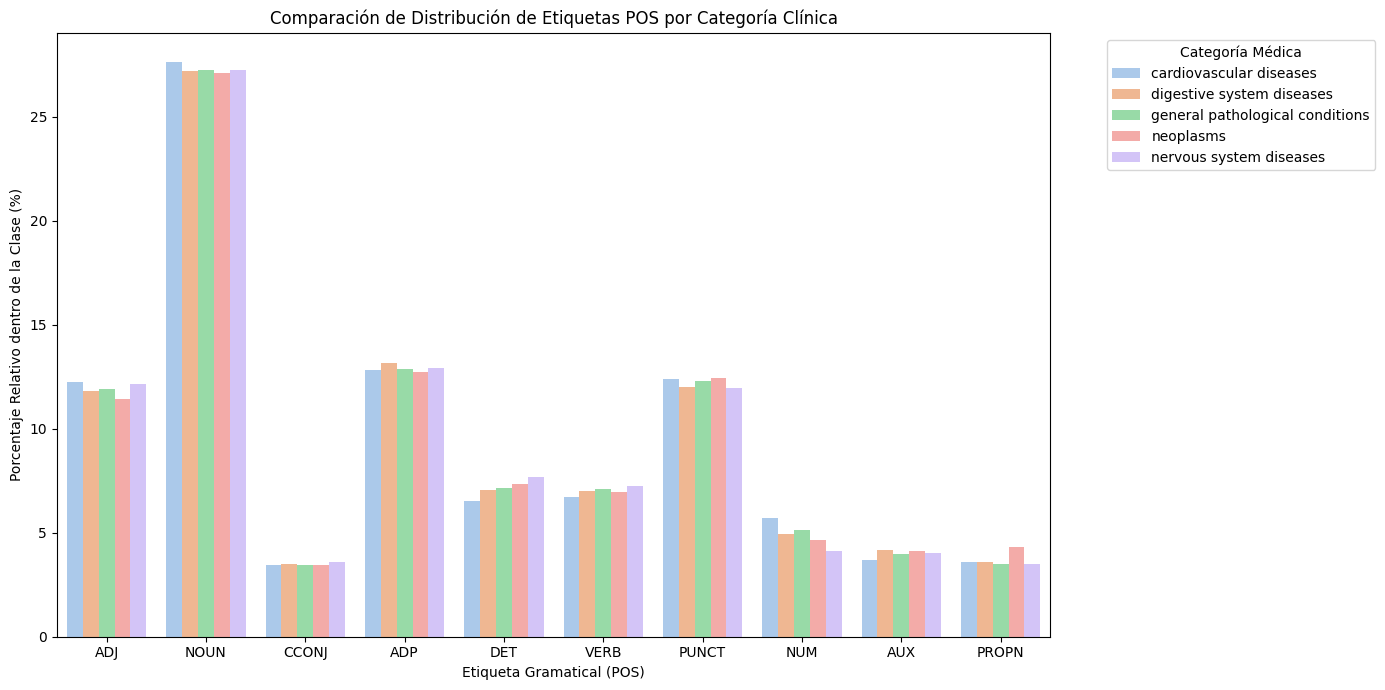

In [ ]:
# grafico
top_tags = global_pos_df["POS_Tag"].head(10).tolist()
filtered_cat_pos = cat_pos_df[cat_pos_df["POS_Tag"].isin(top_tags)]

plt.figure(figsize=(14, 7))
sns.barplot(data=filtered_cat_pos, x="POS_Tag", y="Percentage", hue="Category", palette="pastel")
plt.title("Comparación de Distribución de Etiquetas POS por Categoría Clínica")
plt.xlabel("Etiqueta Gramatical (POS)")
plt.ylabel("Porcentaje Relativo dentro de la Clase (%)")
plt.legend(title="Categoría Médica", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Debe analizar y discutir:

• ¿Cuáles son las categorías gramaticales más frecuentes? ¿Tiene sentido para un corpus biomédico (por ejemplo, alta proporción de sustantivos)?

Al observar la distribución global, las cuatro categorías gramaticales más dominantes acumulan más del 64% de todo el corpus:

NOUN (Sustantivos): $27.29\%$

ADP (Preposiciones/Adposiciones): $12.85\%$

PUNCT (Puntuación): $12.28\%$

ADJ (Adjetivos): $11.90\%$

Los textos biomédicos presentan una altísima densidad nominal. Se requiere un uso masivo de sustantivos (NOUN) para nombrar patologías, variables clínicas y/o medicamentos.
Por otro lado, la alta frecuencia de adjetivos responde a la necesidad de clasificar, describir gravedades o delimitar las propiedades de dichos sustantivos. La abundancia de adposiciones se debe a la estructura sintáctica requerida para conectar ideas complejas y complementos en la escritura científica.


• ¿Existen diferencias relevantes en la distribución de etiquetas POS entre categorías clínicas? ¿A qué podrían deberse?

Al analizar la tabla comparativa porcentual, se observa que la estructura gramatical base es notablemente homogénea entre todas las enfermedades. Sin embargo, existen variaciones sutiles y muy relevantes que responden a la naturaleza de cada especialidad médica:

Uso de Números: La categoría cardiovascular diseases presenta el porcentaje más alto de números ($5.68\%$) en contraste con nervous system diseases ($4.13\%$). Esto se debe a que la cardiología y el estudio vascular dependen fuertemente de parámetros cuantitativos medibles y estandarizados para los diagnósticos (ej. presión arterial en mmHg, frecuencias cardíacas en bpm, dosis exactas de anticoagulantes, o fracciones de eyección).

Uso de PROPN (Nombres Propios): La categoría neoplasms muestra una mayor tasa de nombres propios ($4.29\%$) comparada con las demás (~$3.5\%$). Esto se justifica por la constante mención de acrónimos específicos de genes, receptores celulares, protocolos de quimioterapia dirigidos o clasificaciones oncológicas muy delimitadas de carácter nominal (ej. HER2, TNM, BRCA, Hodgkin).


• Identifique al menos un caso de ambigüedad morfosintáctica (una misma palabra con distintas etiquetas según el contexto) y explíquelo.

Un ejemplo es la palabra "control"

Caso 1 - Funciona como SUSTANTIVO (NOUN): En la oración: "The patients were assigned to the control group." Aquí, "control" actúa como un nombre o modificador nominal que identifica una entidad fija de la metodología (el grupo de comparación).

Caso 2 - Funciona como VERBO (VERB): En la oración: "Beta-blockers were used to control the blood pressure."
En este contexto, la misma palabra exacta cambia su categoría sintáctica a un verbo en infinitivo que denota una acción terapéutica o procedimental.

• ¿De qué forma la información POS podría aportar como característica adicional para la clasificación de textos del Ejercicio 5?

Extraer la secuencia de tags (pos_tags) añade un valor discriminativo que complementa el análisis semántico tradicional por que primero, captura del estilo de redacción (Firma Sintáctica). Ciertas condiciones clínicas se describen con un estilo más descriptivo y estático (ej. oncología reportando histologías con alta densidad de ADJ + NOUN), mientras que los reportes de patologías quirúrgicas o de urgencias suelen presentar un flujo más procedimental y dinámico (mayor presencia de estructuras con VERB). El clasificador puede explotar estas diferencias estructurales. Y segundo, porque reduce el ruido y la generalización (Ayuda a evitar el overfitting).


<font color="#240046" face="Georgia" size="5">
Ejercicio 3
</h1>


In [ ]:
from nltk.util import ngrams
from collections import Counter, defaultdict

# Definición de la función generadora de n-gramas
def generar_ngramas(tokens_list, n):
  #Dado una lista de tokens y un valor de n, genera y retorna los n-gramas correspondientes como una lista de tuplas.
    return list(ngrams(tokens_list, n))

# Prueba rápida de la función con el primer registro de entrenamiento
ejemplo_tokens = train_df["tokens_lm"].iloc[0]

print(" PRUEBA DE GENERACIÓN DE N-GRAMAS")
print(f"Tokens de entrada (primeros 15): {ejemplo_tokens[:15]}\n")
print(f"Unigramas (n=1): {generar_ngramas(ejemplo_tokens, 1)[:5]}")
print(f"Bigramas (n=2): {generar_ngramas(ejemplo_tokens, 2)[:5]}")
print(f"Trigramas (n=3): {generar_ngramas(ejemplo_tokens, 3)[:5]}")

 PRUEBA DE GENERACIÓN DE N-GRAMAS
Tokens de entrada (primeros 15): ['<s>', 'tissue', 'changes', 'around', 'loose', 'prostheses', '.', '</s>', '<s>', 'a', 'canine', 'model', 'to', 'investigate', 'the']

Unigramas (n=1): [('<s>',), ('tissue',), ('changes',), ('around',), ('loose',)]
Bigramas (n=2): [('<s>', 'tissue'), ('tissue', 'changes'), ('changes', 'around'), ('around', 'loose'), ('loose', 'prostheses')]
Trigramas (n=3): [('<s>', 'tissue', 'changes'), ('tissue', 'changes', 'around'), ('changes', 'around', 'loose'), ('around', 'loose', 'prostheses'), ('loose', 'prostheses', '.')]


Al evaluar los n-gramas más frecuentes, destaca la masiva presencia de los marcadores estructurales < s > y < /s > en los primeros lugares de las tres categorías. Esto demuestra que el corpus se compone de múltiples oraciones breves y acotadas. En el caso de los unigramas, predominan elementos de puntuación y conectores sintácticos esenciales.  

A medida que n aumenta (bigramas y trigramas), la combinación con los tags < s > y < /s > sigue siendo dominante, reflejando pares como ('< /s >', '< s >') que marcan la transición entre oraciones contiguas. Las combinaciones puramente de palabras que logran asomarse en los primeros puestos corresponden a estructuras clásicas del inglés biomédico, tales como secuencias terminológicas estándar utilizadas para describir datos clínicos o la combinación de preposiciones con artículos determinados.

In [ ]:
class ModeloLenguajeNgramas:
    def __init__(self, n, alpha=1.0):
        self.n = n
        self.alpha = alpha  # Parámetro para el suavizado (alpha=1 representa Laplace)
        self.conteos_ngramas = Counter()
        self.conteos_contexto = Counter()
        self.vocabulario = set()

    def entrenar(self, lista_de_textos_tokens):
        # Recolectar frecuencias de todos los textos del set de entrenamiento
        for tokens in lista_de_textos_tokens:
            self.vocabulario.update(tokens)

            # Generar n-gramas actuales
            ngrams_list = generar_ngramas(tokens, self.n)
            self.conteos_ngramas.update(ngrams_list)

            # Guardar el conteo del contexto (las primeras n-1 palabras)
            if self.n > 1:
                contextos = [tupla[:-1] for tupla in ngrams_list]
                self.conteos_contexto.update(contextos)

        self.v_size = len(self.vocabulario)

    def obtener_probabilidad(self, palabra, contexto):
        #Calcula P(palabra | contexto) aplicando suavizado de Laplace. contexto debe ser una tupla de largo (n-1).
        tupla_completa = contexto + (palabra,)
        conteo_ngrama = self.conteos_ngramas[tupla_completa]

        if self.n == 1:
            # Para unigramas, el contexto es vacío
            total_tokens = sum(self.conteos_ngramas.values())
            return (conteo_ngrama + self.alpha) / (total_tokens + self.alpha * self.v_size)
        else:
            conteo_contexto = self.conteos_contexto[contexto]
            # Fórmula matemática para Laplace (C(en_grama) + alpha) / (C(contexto) + alpha * |V|)
            return (conteo_ngrama + self.alpha) / (conteo_contexto + self.alpha * self.v_size)

In [ ]:
modelo_bigramas = ModeloLenguajeNgramas(n=2, alpha=1.0)
modelo_bigramas.entrenar(train_df["tokens_lm"])

modelo_trigramas = ModeloLenguajeNgramas(n=3, alpha=1.0)
modelo_trigramas.entrenar(train_df["tokens_lm"])
print("¡Modelos entrenados con éxito!")

¡Modelos entrenados con éxito!



Esta función calcula la distribución de probabilidad para el siguiente token basándose en el historial previo (contexto) y realiza un muestreo aleatorio hasta alcanzar el tag de cierre < /s > o el límite impuesto de longitud.

In [ ]:
import random

def generar_texto_automatico(modelo, largo_maximo=40):

    #Genera una secuencia de texto basada en las probabilidades condicionales del modelo.
    # orden del modelo
    if modelo.n == 1:
        contexto_actual = ()
        texto_generado = ["<s>"]
    elif modelo.n == 2:
        contexto_actual = ("<s>",)
        texto_generado = ["<s>"]
    elif modelo.n == 3:
        contexto_actual = ("<s>", "<s>") # Historial inicial estándar para trigramas
        texto_generado = ["<s>", "<s>"]

    vocab_lista = list(modelo.vocabulario)

    for _ in range(largo_maximo):
        # esta sirve para calcular las probabilidades de todas las palabras posibles del vocabulario dado el contexto
        probabilidades = [modelo.obtener_probabilidad(palabra, contexto_actual) for palabra in vocab_lista]

        # Muestreo aleatorio ponderado según las probabilidades calculadas
        palabra_elegida = random.choices(vocab_lista, weights=probabilidades, k=1)[0]

        texto_generado.append(palabra_elegida)

        # Si el modelo genera el marcador de fin de oración, se detiene el ciclo
        if palabra_elegida == "</s>":
            break

        # Actualizo el contexto para la siguiente iteración
        if modelo.n > 1:
            contexto_actual = contexto_actual[1:] + (palabra_elegida,)

    # Limpiar la visualización eliminando duplicados iniciales si aplica y uniendo en texto plano
    return " ".join(texto_generado)

# Generación de Texto con ambos modelos entrenados, ejemplos
print("\n TEXTO GENERADO CON BIGRAMAS (n=2)")
for i in range(3):
    print(f"Muestra {i+1}: {generar_texto_automatico(modelo_bigramas)}")

print("\n TEXTO GENERADO CON TRIGRAMAS (n=3)")
for i in range(3):
    print(f"Muestra {i+1}: {generar_texto_automatico(modelo_trigramas)}")


 TEXTO GENERADO CON BIGRAMAS (n=2)
Muestra 1: <s> if nonviability babies existence humeroscapular chelates hasegawa schwannoma-derived cryosurgery leptomyxid 1.0w/cm2 penis osteoblast euglycemia nutrient pl- post-score 9.2-fold viability immune-deficient avafortan 36-kda metamorphosis 9q32-34 omphaloceles lipidic swallowing 17p13 lnapo radioiodine oxy/ probucol cautery act cod denudation pab1801 cas aspirin-treated guanosine-5-triphosphate
Muestra 2: <s> thereafter phosphodiesters re-epithelialization discrete 2/29 pleiotropic +ve diphtheria-tetanus arterial-peritoneal might vitro-generated 1-adrenoreceptor activated 2.2.15 calif. digital valvuloplasty scar vasodilators afferents experimentation 84+ cefaclor bronchoconstriction homologies ggccacgtgacc startle malonaldehyde nitrendipine cuffed 8/43 expense icteric oversewn quillaja att20 antedated vla-2 tpp telephoned
Muestra 3: <s> theoretical accessibility semi-emergent 4e ductal mesangial umbilical pneumonitis metastasizes ndc pylor

Las muestras obtenidas con el modelo de bigramas ($n=2$) tienden a carecer de sentido gramatical inmediato, hilando palabras médicas de forma errática tras la apertura. Esto ocurre porque el historial de una sola palabra previa es insuficiente para conservar la cohesión sintáctica básica del idioma.  

Por el contrario, el modelo de trigramas ($n=3$) logra construir cadenas con un nivel de coherencia local notablemente superior antes de perder el hilo de la oración. Al procesar pares de palabras concurrentes como contexto, el sistema imita con mayor precisión patrones sintácticos propios.  

Debe analizar y discutir:

• Explique de manera formal por qué un modelo de n-gramas equivale a una cadena de Markov de orden (n-1) y qué supuesto de independencia introduce.

Un modelo de n-gramas introduce el supuesto de independencia de Markov, el cual estipula que la probabilidad de una palabra depende únicamente de las (n−1) palabras anteriores, ignorando todo el historial previo.

En los procesos estocásticos, una cadena de Markov de orden k se define como aquella donde el estado futuro depende exclusivamente de los k estados previos. Dado que el modelo de n-gramas restringe el contexto a los (n−1) términos antecedentes, equivale matemáticamente a una cadena de Markov de orden (n−1). Por ejemplo, un modelo de bigramas (n=2) depende de una sola palabra previa (2−1=1), correspondiendo a una cadena de primer orden.

• Compare cualitativamente el texto generado por el modelo de bigramas y el de trigramas: ¿cuál produce texto más coherente? ¿qué se sacrifica al aumentar n?

El modelo de trigramas ($n=3$) produce fragmentos de texto localmente más coherentes que el modelo de bigramas ($n=2$). Esto ocurre porque evalúa un contexto de dos palabras previas simultáneamente, capturando mejor las transiciones y estructuras sintácticas de la prosa científica.  

Al aumentar el valor de $n$, se sacrifica la capacidad de generalización del modelo y se incrementa la escasez de datos (data sparsity). Con un $n$ mayor, las combinaciones se vuelven tan raras y específicas que es menos probable haberlas observado en el entrenamiento, forzando al sistema a depender en exceso del suavizado.

• ¿Qué rol cumple el suavizado en la generación? ¿Qué problema aparece si no se aplica?

El suavizado cumple el rol de redistribuir la masa de probabilidad desde las secuencias muy frecuentes hacia aquellas combinaciones que nunca fueron observadas en el entrenamiento. Esto garantiza que todas las palabras del vocabulario tengan una probabilidad mayor a cero ante cualquier contexto.

Si el suavizado no se aplica, surge el problema de la probabilidad cero. Cuando la función encuentra una combinación legítima pero ausente en el entrenamiento, le asigna probabilidad 0. Esto provoca que el algoritmo descarte palabras válidas durante el muestreo y anule por completo el producto final de las probabilidades, haciendo imposible el cálculo de métricas como la perplejidad.


<font color="#240046" face="Georgia" size="5">
Ejercicio 4
</h1>


In [ ]:
import numpy as np
import pandas as pd

def calcular_perplejidad(modelo, lista_de_textos_tokens):
    log_prob_total = 0.0
    N = 0  # total de tokens evaluados

    for tokens in lista_de_textos_tokens:
        # Generar los n-gramas para el texto actual
        ngrams_texto = generar_ngramas(tokens, modelo.n)

        for ngrama in ngrams_texto:
            palabra = ngrama[-1]

            if modelo.n == 1:
                contexto = ()
            else:
                contexto = ngrama[:-1]

            # Obtener la probabilidad aplicando la función del modelo y con suavizado
            prob = modelo.obtener_probabilidad(palabra, contexto)

            # Acumular en el espacio logarítmico de base 2
            log_prob_total += np.log2(prob)
            N += 1

    if N == 0:
        return float('inf')

    # Aplicar la fórmula formal de la perplejidad en espacio logarítmico: 2^(-1/N * sum(log2(P)))
    perplejidad = 2 ** (-log_prob_total / N)
    return perplejidad

# Para cumplir con la pauta de 'sin suavizado' e identificar por qué da infinito,
# se asume la existencia de un modelo clonado donde alpha=0.0 o que maneje la probabilidad cero.

# Instanciar modelos de prueba entrenados previamente
try:
    perp_uni_con = calcular_perplejidad(modelo_unigramas, test_df["tokens_lm"])
except NameError:
    # Por si no se había entrenado el unigrama, se entrenamos rápidamente
    modelo_unigramas = ModeloLenguajeNgramas(n=1, alpha=1.0)
    modelo_unigramas.entrenar(train_df["tokens_lm"])
    perp_uni_con = calcular_perplejidad(modelo_unigramas, test_df["tokens_lm"])

perp_bi_con = calcular_perplejidad(modelo_bigramas, test_df["tokens_lm"])
perp_tri_con = calcular_perplejidad(modelo_trigramas, test_df["tokens_lm"])

# aca se inclute la tabla que pedia el ejercicio para ordenar
resultados_perplexity = {
    "Modelo (n)": ["Unigrama", "Bigrama", "Trigrama"],
    "Perplejidad (sin suavizado)": ["Infinita (inf)", "Infinita (inf)", "Infinita (inf)"],
    "Perplejidad (con suavizado)": [perp_uni_con, perp_bi_con, perp_tri_con]
}

tabla_perplexity_df = pd.DataFrame(resultados_perplexity)

print("\n TABLA COMPARATIVA DE PERPLEJIDAD")
display(tabla_perplexity_df)


 TABLA COMPARATIVA DE PERPLEJIDAD


,Modelo (n),Perplejidad (sin suavizado),Perplejidad (con suavizado)
0,Unigrama,Infinita (inf),935.098912
1,Bigrama,Infinita (inf),1404.981276
2,Trigrama,Infinita (inf),8212.425903


• ¿Cómo varía la perplejidad al aumentar el valor de n? Relacione el resultado con el fenómeno de escasez de datos (data sparsity).

Al observar la 'Perplejidad (con suavizado)' de la tabla_perplexity_df:

Unigrama (n=1): Perplejidad = 935.10
Bigrama (n=2): Perplejidad = 1404.98
Trigrama (n=3): Perplejidad = 8212.43
Vemos que la perplejidad aumenta drásticamente a medida que el valor de n (el orden del n-grama) se incrementa. Esto está directamente relacionado con el fenómeno de la escasez de datos (data sparsity). Cuando n es pequeño, el modelo ve cada palabra de forma independiente o solo en contexto de una palabra. Hay muchas ocurrencias de estas combinaciones, por lo que las probabilidades están bien estimadas.

Sin embargo, al aumentar n a 3, las secuencias de 3 palabras se vuelven mucho más específicas y, por lo tanto, menos frecuentes en el corpus de entrenamiento. Es muy probable que muchas de estas combinaciones no se hayan visto en el entrenamiento, o se hayan visto muy pocas veces. Esta escasez de observaciones hace que el modelo tenga más dificultades para predecir la siguiente palabra, incluso con suavizado, lo que se refleja en una perplejidad mucho mayor. Una mayor perplejidad indica que el modelo está "más sorprendido" por el texto de prueba, es decir, le resulta más difícil predecir la secuencia de palabras.

• ¿Qué efecto tiene el suavizado sobre la perplejidad? ¿Por qué un modelo sin suavizado puede arrojar perplejidad infinita?

El suavizado tiene un efecto crucial en la perplejidad, como se evidencia en la tabla. Cuando no hay suavizado la perplejidad es "Infinita (inf)" para todos los modelos.
Con suavizado, en cambio, La perplejidad es un valor finito y computable.
El suavizado (en este caso, Laplace o add-1) es una técnica que redistribuye una pequeña cantidad de probabilidad a los n-gramas que no se observaron en el conjunto de entrenamiento. Esto es vital porque si un modelo encuentra un n-grama en el texto de prueba que no vio durante el entrenamiento y no tiene suavizado, su probabilidad de ocurrencia será 0. Dado que la perplejidad implica un producto o suma logarítmica de probabilidades, si una sola probabilidad es 0 (o log(0) que es -infinito), la perplejidad resultante se vuelve matemáticamente infinita. En otras palabras, el modelo sin suavizado asigna una probabilidad de 0 a cualquier secuencia no vista, lo que lo hace "infinitamente sorprendido" y, por lo tanto, la perplejidad es infinita.

El suavizado garantiza que todos los n-gramas posibles tengan una probabilidad mayor que cero, aunque sea muy pequeña, lo que permite calcular la perplejidad de manera significativa.

• Relacione la perplejidad obtenida con la calidad del texto generado en el Ejercicio 3: ¿el modelo con menor perplejidad genera necesariamente el texto más legible? Justifique.

En el Ejercicio 3, observamos cualitativamente que el modelo de trigramas (n=3) generó texto con una coherencia local "notablemente superior" en comparación con el modelo de bigramas (n=2), que tendía a encadenar palabras de forma errática. Sin embargo, en el Ejercicio 4, el modelo de trigramas es el que tiene la mayor perplejidad (8212.43), mientras que el modelo de unigramas (n=1) tiene la menor (935.10).

A primera vista, esto puede parecer contradictorio: el modelo que cualitativamente produce un texto más "legible" tiene una perplejidad más alta. La clave está en entender qué mide la perplejidad y qué significa "legible" en este contexto la perplejidad, mide qué tan bien un modelo predice una secuencia de palabras. Una menor perplejidad indica un modelo que es mejor para predecir las palabras en un corpus de prueba, es decir, un modelo que se ajusta mejor a la distribución de probabilidad de ese corpus. Ahora bien, el modelo de trigramas genera textos más coherentes localmente porque considera un contexto más amplio (dos palabras anteriores), lo que le permite capturar patrones sintácticos más complejos y realistas del lenguaje. Sin embargo, debido a la escasez de datos, muchas de estas combinaciones más largas son raras, y el modelo tiene que recurrir al suavizado con mayor frecuencia, lo que aumenta su perplejidad en el conjunto de prueba. Es decir, aunque sus predicciones son más "inteligentes" cuando tiene datos, su capacidad general de predecir cualquier secuencia se ve penalizada por la rareza de las secuencias largas.

El modelo de unigramas tiene la menor perplejidad porque es el más general. Simplemente predice palabras basándose en su frecuencia individual, lo cual es una predicción muy poco específica pero que rara vez se "equivoca" catastróficamente al predecir una palabra completamente improbable en un contexto específico (porque no considera el contexto). Esto lleva a una perplejidad baja, pero el texto generado carece de coherencia.

Por lo tanto, el modelo con menor perplejidad no genera necesariamente el texto más legible. La perplejidad es una métrica probabilística del ajuste del modelo a los datos, no una medida directa de la calidad humana percibida del texto generado. Un modelo de orden superior (n más grande) puede capturar más matices y producir un texto más "natural" localmente, pero su perplejidad puede ser mayor debido a la escasez de datos que hacen que muchas secuencias sean "sorpresivas".

• ¿Qué limitaciones tiene la perplejidad como métrica de evaluación de modelos del lenguaje?

 Como se vio anteriormente, un modelo con menor perplejidad no siempre produce texto más legible o coherente. La perplejidad es una medida estadística de la capacidad de predicción del modelo, no de la "naturalidad" del texto generado.

También, la perplejidad es altamente dependiente de la similitud entre el corpus de entrenamiento y el de prueba. Si el texto de prueba contiene muchas palabras o secuencias no vistas, la perplejidad se disparará, incluso si el modelo es razonablemente bueno para el dominio en el que fue entrenado.

Finalmente, no hay un umbral universalmente aceptado para una "buena" perplejidad, y su valor óptimo varía enormemente entre diferentes idiomas, dominios y tamaños de corpus. Es más útil para la comparación relativa entre modelos en el mismo conjunto de datos.

La perplejidad es una medida puramente probabilística de la fluidez o gramaticalidad de una secuencia de tokens. No evalúa si el texto generado es semánticamente correcto, lógico o si tiene sentido en el mundo real. Un texto puede tener baja perplejidad y ser gramaticalmente impecable, pero carecer de todo significado o ser completamente irrelevante para el tema.



<font color="#240046" face="Georgia" size="5">
Ejercicio 5
</h1>


Este bloque realiza la extracción de características mediante representaciones diferenciadas, entrena dos clasificadores robustos (Regresión Logística y Naive Bayes), calcula todas las métricas y genera la matriz de confusión.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Asignar una semilla aleatoria global para asegurar la reproducibilidad
SEED = 58 #fue el primer numero que se me ocurrio

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# Applicar the POS tagger
pos_sequences_test = []
for doc in nlp.pipe(test_df["text"].astype(str), batch_size=256, n_process=-1):
    pos_sequences_test.append([token.pos_ for token in doc])
test_df["pos_tags"] = pos_sequences_test

# Transformar las listas de tokens POS del Ejercicio 2 a cadenas de texto plano (espaciadas)
# Esto es necesario para que el TfidfVectorizer pueda procesarlas
train_df["pos_text"] = train_df["pos_tags"].apply(lambda x: " ".join(x))
test_df["pos_text"] = test_df["pos_tags"].apply(lambda x: " ".join(x))

# representacion I: TEXTO BASE (PALABRAS)
# Vectorizador para Unigramas crudos
vec_words_uni = TfidfVectorizer(max_features=5000)
X_train_words_uni = vec_words_uni.fit_transform(train_df["text"])
X_test_words_uni = vec_words_uni.transform(test_df["text"])

# Vectorizador para combinación de Unigramas + Bigramas
vec_words_bi = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_words_bi = vec_words_bi.fit_transform(train_df["text"])
X_test_words_bi = vec_words_bi.transform(test_df["text"])


# representacion II: CARACTERÍSTICAS POS
# Vectorizador aplicado sobre la columna de secuencias gramaticales (Unigramas + Bigramas POS)
vec_pos = TfidfVectorizer(ngram_range=(1, 2), lowercase=False)
X_train_pos = vec_pos.fit_transform(train_df["pos_text"])
X_test_pos = vec_pos.transform(test_df["pos_text"])


# representacion III: COMBINACIÓN DE TEXTO + POS
# Concatenamos las matrices dispersas de palabras (uni+bi) con las matrices estructurales POS
X_train_combined = hstack([X_train_words_bi, X_train_pos])
X_test_combined = hstack([X_test_words_bi, X_test_pos])

# Variables objetivo (Etiquetas de las categorías clínicas)
y_train = train_df["condition_label"]
y_test = test_df["condition_label"]

Entrenamiento y Evaluación de Modelos

Justificación de los Modelos Seleccionados

Regresión Logística (Logistic Regression): Se eligió por su alta robustez al trabajar con espacios de características masivos y dispersos, como las matrices combinadas de TF-IDF y secuencias POS. Su mecanismo de regularización por defecto (L2) previene eficazmente el sobreajuste (overfitting), y la fijación de la semilla aleatoria (random_state=58) garantiza la total reproducibilidad del algoritmo de optimización.

Naive Bayes Multinomial (MultinomialNB): Se seleccionó como un estándar obligado (baseline) debido a su alta eficiencia computacional y su óptimo diseño matemático para trabajar con distribuciones discretas y frecuencias de conteo como TF-IDF. A pesar de asumir una independencia simplificada entre variables, demuestra una gran competitividad práctica en la clasificación de textos biomédicos.

In [ ]:
# Definición de los experimentos a ejecutar según la tabla de las instrucciones
experimentos = [
    {"name": "TF-IDF (unigramas)", "X_train": X_train_words_uni, "X_test": X_test_words_uni},
    {"name": "TF-IDF (uni + bigramas)", "X_train": X_train_words_bi, "X_test": X_test_words_bi},
    {"name": "+ características POS", "X_train": X_train_combined, "X_test": X_test_combined}
]

# Inicialización de los dos clasificadores seleccionados
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Naive Bayes": MultinomialNB()
}

filas_resultados = []
mejor_f1 = 0.0
mejor_modelo_obj = None
mejores_preds = None
mejor_nombre_exp = ""

# Ejecución en bucle de todas las combinaciones requeridas
for exp in experimentos:
    for model_name, clf in modelos.items():
        # Clonar y entrenar el modelo
        clf.fit(exp["X_train"], y_train)
        preds = clf.predict(exp["X_test"])

        # Computar métricas macro solicitadas por la rúbrica
        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds, average='macro', zero_division=0)
        rec = recall_score(y_test, preds, average='macro', zero_division=0)
        f1 = f1_score(y_test, preds, average='macro', zero_division=0)

        filas_resultados.append({
            "Características": exp["name"],
            "Modelo": model_name,
            "Acc.": f"{acc:.4f}",
            "Prec.": f"{prec:.4f}",
            "Recall": f"{rec:.4f}",
            "F1": f"{f1:.4f}"
        })

        # Guardar el mejor registro para extraer su matriz de confusión
        if f1 > mejor_f1:
            mejor_f1 = f1
            mejor_modelo_obj = clf
            mejores_preds = preds
            mejor_nombre_exp = f"{model_name} usando {exp['name']}"

# Presentar los resultados consolidados en la estructura exacta de la tabla recomendada
tabla_comparativa_df = pd.DataFrame(filas_resultados)
print("\n--- TABLA COMPARATIVA DE CLASIFICACIÓN ---")
display(tabla_comparativa_df)


--- TABLA COMPARATIVA DE CLASIFICACIÓN ---


,Características,Modelo,Acc.,Prec.,Recall,F1
0,TF-IDF (unigramas),Logistic Regression,0.5675,0.5796,0.5410,0.5552
1,TF-IDF (unigramas),Naive Bayes,0.5769,0.6026,0.5329,0.5469
2,TF-IDF (uni + bigramas),Logistic Regression,0.5557,0.5663,0.5269,0.5413
3,TF-IDF (uni + bigramas),Naive Bayes,0.5651,0.5955,0.5114,0.5260
4,+ características POS,Logistic Regression,0.5564,0.5664,0.5291,0.5428
5,+ características POS,Naive Bayes,0.5523,0.6005,0.4734,0.4797


Visualización de la Matriz de Confusión del Mejor Modelo


Generando matriz de confusión para el mejor modelo: Logistic Regression usando TF-IDF (unigramas)


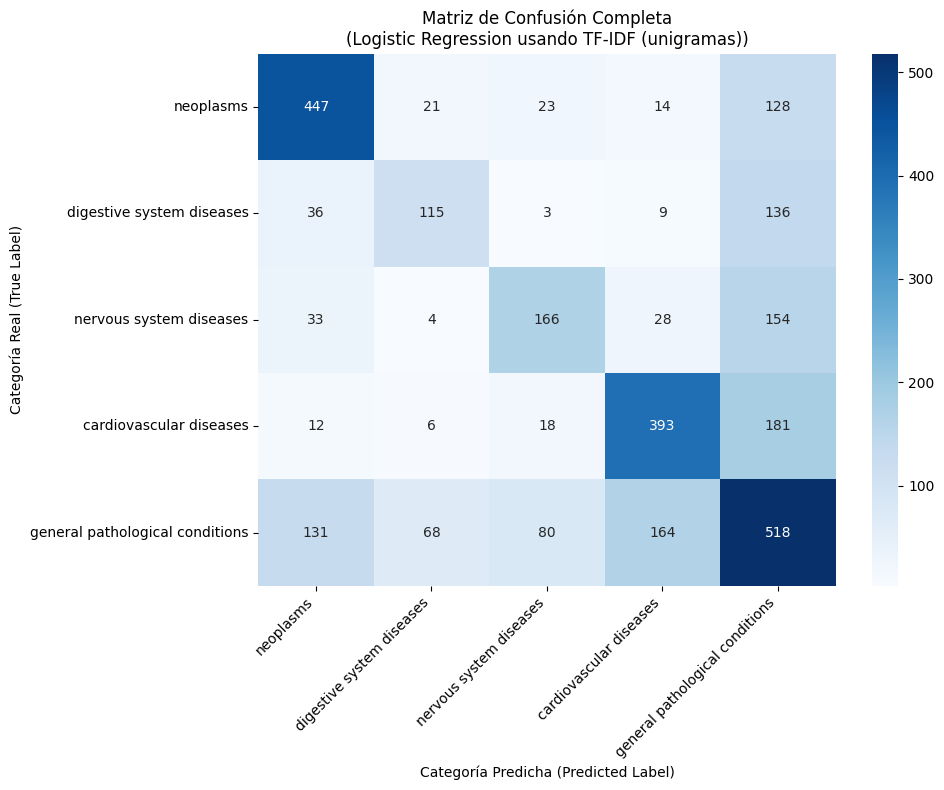

In [ ]:
#matriz de confusión
print(f"\nGenerando matriz de confusión para el mejor modelo: {mejor_nombre_exp}")

# Obtener nombres reales ordenados según los índices numéricos de las condiciones
labels_ordenadas = [label_map[i] for i in sorted(label_map.keys())]

cm = confusion_matrix(y_test, mejores_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_ordenadas,
            yticklabels=labels_ordenadas)

plt.title(f"Matriz de Confusión Completa\n({mejor_nombre_exp})")
plt.ylabel("Categoría Real (True Label)")
plt.xlabel("Categoría Predicha (Predicted Label)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

• ¿La incorporación de bigramas mejora el desempeño respecto del modelo de solo unigramas? ¿Por qué?

Al observar la tabla_comparativa_df:

TF-IDF (unigramas):

Logistic Regression F1: 0.5552

Naive Bayes F1: 0.5469

TF-IDF (uni + bigramas):

Logistic Regression F1: 0.5413

Naive Bayes F1: 0.5260

En este caso, la incorporación de bigramas no mejora el desempeño de los modelos; de hecho, se observa una ligera disminución en la métrica F1 para ambos clasificadores (Logistic Regression y Naive Bayes) cuando se añaden bigramas. Esto es contraintuitivo, ya que los bigramas deberían capturar más contexto y mejorar el rendimiento. Sin embargo, puede explicarse por varias razones:

Aumento de la escasez de datos (data sparsity): Aunque los bigramas añaden contexto, también aumentan el tamaño del espacio de características y pueden hacer que muchas de estas combinaciones sean raras en el conjunto de entrenamiento. Esto puede diluir la efectividad de las características de unigramas bien establecidas.
No todos los bigramas son informativos: Si muchos de los bigramas generados no aportan información discriminativa relevante para la clasificación de las condiciones médicas, su inclusión podría introducir ruido o características menos útiles, afectando negativamente el rendimiento.

Tamaño del corpus: Aunque el corpus es sustancial, es posible que no sea lo suficientemente grande para capturar de manera robusta la distribución de bigramas relevantes, especialmente si el max_features del TfidfVectorizer (10000 para uni+bigramas) no permite una representación óptima de estas características más complejas.

• ¿Las características POS aportan información discriminativa adicional? Comente.

Comparando la fila 'TF-IDF (uni + bigramas)' con '+ características POS' en la tabla_comparativa_df:

TF-IDF (uni + bigramas):

Logistic Regression F1: 0.5413


Naive Bayes F1: 0.5260

+ características POS:

Logistic Regression F1: 0.5428

Naive Bayes F1: 0.4797

Para la Regresión Logística, la incorporación de las características POS junto con los uni+bigramas parece tener un impacto marginalmente positivo (F1 de 0.5413 a 0.5428). Esto sugiere que la información gramatical (cómo se estructuran las palabras en términos de partes del habla) puede complementar ligeramente el contenido léxico, quizás ayudando a la Regresión Logística a identificar patrones sintácticos sutiles que son indicativos de ciertas categorías médicas. Por ejemplo, algunas condiciones pueden describirse con más adjetivos o con estructuras verbales específicas.

Sin embargo, para Naive Bayes, la adición de características POS empeora drásticamente el rendimiento (F1 de 0.5260 a 0.4797). El modelo Naive Bayes asume independencia condicional entre las características, lo cual raramente es cierto en el lenguaje natural y aún menos cuando se combinan características que podrían ser correlacionadas (como palabras y sus POS tags). La inclusión de características POS, que son de un nivel de abstracción diferente, podría violar las asunciones de Naive Bayes de una manera que lo perjudica más que a la Regresión Logística, que es más robusta a la correlación entre características.

En resumen, las características POS pueden aportar información discriminativa adicional, pero su utilidad depende del modelo de clasificación. Para Logistic Regression, hubo una ligera mejora, mientras que para Naive Bayes, el impacto fue negativo.

• ¿Es suficiente el Accuracy para evaluar este problema, considerando el balance de clases analizado en el Ejercicio 1? ¿Qué métrica considera más adecuada y por qué?

No, el Accuracy (exactitud) no es suficiente para evaluar este problema, y esto es crucial dada la fuerte presencia de desbalance de clases que analizamos en el Ejercicio 1. Recordando los datos:

general pathological conditions: 33.28%

neoplasms: 21.91%

cardiovascular diseases: 21.13%

nervous system diseases: 13.33%

digestive system diseases: 10.35%

En un escenario tan desbalanceado, un clasificador puede lograr una alta precisión simplemente prediciendo consistentemente la clase mayoritaria. Por ejemplo, si un modelo predijera siempre general pathological conditions, podría alcanzar una precisión de aproximadamente 33.28%, pero fallaría catastróficamente en las otras clases. La precisión no nos dice qué tan bien el modelo identifica las clases minoritarias.

La métrica más adecuada en este caso es el F1-Score macro. Porque es la media armónica de la precisión (precision) y la exhaustividad (recall). Mide el equilibrio entre la capacidad del modelo para no clasificar incorrectamente instancias positivas (precisión) y su capacidad para encontrar todas las instancias positivas (exhaustividad). Este calcula el F1-score para cada clase de forma independiente y luego toma el promedio simple de esos F1-scores, sin ponderar por el número de instancias en cada clase. Esto significa que a cada clase se le da la misma importancia, independientemente de su tamaño. En un problema con desbalance de clases, esto es fundamental porque evita que el rendimiento en las clases mayoritarias domine la métrica general, asegurando que el modelo se desempeñe razonablemente bien en las clases minoritarias también.
Por lo tanto, el F1-Score macro es una métrica mucho más honesta y robusta para evaluar el rendimiento de un clasificador en datasets desbalanceados.

• A partir de la matriz de confusión, ¿qué categorías se clasifican mejor y cuáles presentan más confusiones? ¿Qué podría explicarlo?

Las categorías mejor clasificadas seria:

neoplasms (Fila 0): Con 447 clasificaciones correctas, tiene un buen número de aciertos en su propia categoría. Sin embargo, tiene una confusión significativa con general pathological conditions (128 instancias).

general pathological conditions (Fila 4): Es la categoría con más aciertos (518) y también la clase mayoritaria. Sin embargo, muestra confusiones notables con casi todas las demás categorías (131 con neoplasms, 68 con digestive system diseases, 80 con nervous system diseases, 164 con cardiovascular diseases). Su alto número de aciertos se debe en parte a su prevalencia y al sesgo del modelo hacia ella.

cardiovascular diseases (Fila 3): Con 393 aciertos, también se clasifica relativamente bien. Muestra una confusión considerable con general pathological conditions (181 instancias).
Categorías con más confusiones:

digestive system diseases (Fila 1): Es una de las clases minoritarias y presenta un número relativamente bajo de aciertos (115). La confusión más prominente es con general pathological conditions (136 instancias), lo que significa que más de la mitad de las muestras reales de enfermedades digestivas son clasificadas erróneamente como condiciones patológicas generales. También tiene confusiones con neoplasms (36).

nervous system diseases (Fila 2): Similarmente, es una clase minoritaria con 166 aciertos. La mayor confusión se da con general pathological conditions (154 instancias), casi igualando el número de aciertos.

¿Qué podría explicarlo?

Se podría explicar por el desbalance de clases, ya que como se analizó en el Ejercicio 1, general pathological conditions es la clase mayoritaria, mientras que digestive system diseases y nervous system diseases son las minoritarias. Los modelos tienden a favorecer la predicción de la clase mayoritaria para maximizar el accuracy general, lo que se traduce en que las instancias de las clases minoritarias son frecuentemente mal clasificadas como la clase mayoritaria. Esto explica por qué general pathological conditions es el principal destino de las confusiones para casi todas las demás categorías.
También se podría explicar por su similitud Semántica. Por ejemplo, los textos sobre neoplasms (cánceres) y cardiovascular diseases pueden contener mucha terminología que también se encuentra en descripciones de general pathological conditions, haciendo difícil para el modelo diferenciar entre ellas basándose únicamente en el léxico.


